In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2, norm

def head(obj, n=6):
    if hasattr(obj, 'head'):
        return obj.head(n)
    return obj[:n]

sns.set_theme(style='whitegrid')


In [2]:
import numpy as np
from math import sqrt
from scipy.stats import binom, chi2, chisquare, f, hypergeom, nct, norm, poisson, t


## Exercise 6.1. Before we start


To run the exercises in this workshop, we need to load a few packages.


In [3]:
# Python equivalent setup for plotting and data manipulation
sns.set_theme(style='whitegrid')


## Exercise 6.2.  Customer satisfaction survey


The client satisfaction results from Table 6.3


In [4]:
# Hypothesized population proportions from the base year
p = np.array([0.40, 0.16, 0.44])


Results from the follow-up study


In [5]:
# Observed frequencies from the follow-up study
observed = np.array([15, 12, 13])
# Sample size
n = sum(observed)


The expected frequencies are therefore obtained by multiplying these
proportions by the sample size.


In [6]:
# Expected frequencies
expected = n * p


The chi-square test statistic is


In [7]:
# Chi-square test statistic (manual calculation)
chi_sq = sum((observed - expected)**2 / expected)


Calculation of the critical value


In [8]:
# Degrees of freedom
df = len(observed) - 1
# Critical value for alpha = 0.05
alpha = 0.05
critical_value = chi2.ppf(1 - alpha, df=df)


Calculation of the p-value


In [9]:
p_value = chi2.sf(chi_sq, df=df)


Using the built-in test


In [10]:
(lambda _obs, _p: chisquare(f_obs=_obs, f_exp=_obs.sum() * (_p / _p.sum())))(np.asarray(observed, dtype=float), np.asarray(p, dtype=float))


Power_divergenceResult(statistic=np.float64(6.1647727272727275), pvalue=np.float64(0.04584971190900036))

### Benford's Law


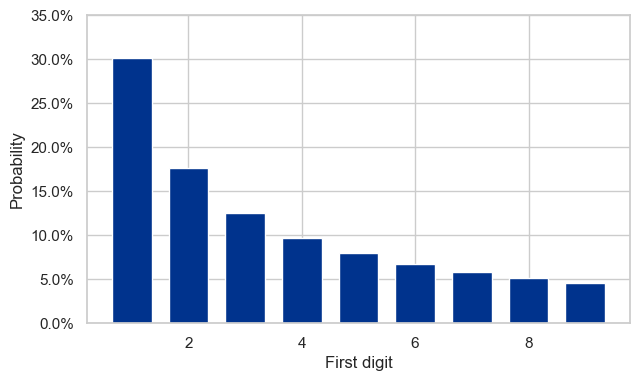

In [11]:
digits = np.arange(1, 10)
probabilities = np.log10((digits + 1) / digits)
benford = pd.DataFrame({'Digit': digits, 'Probability': probabilities})
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(benford['Digit'], benford['Probability'], color='#00338D', width=0.7)
ax.set_xlabel('First digit')
ax.set_ylabel('Probability')
ax.set_ylim(0, 0.35)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.show()


### Examples from Benford


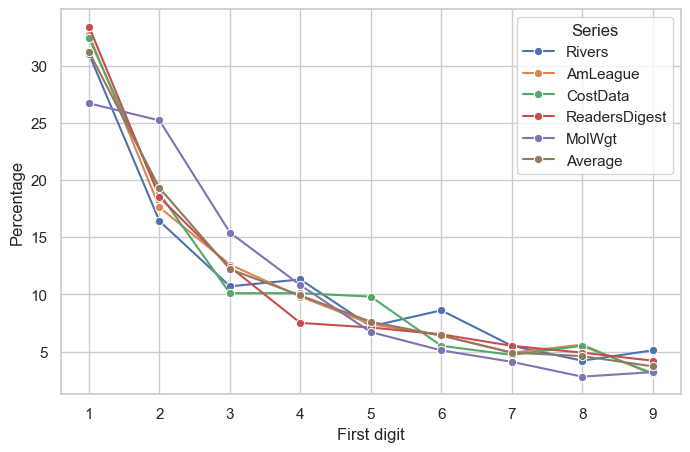

In [12]:
df = pd.DataFrame({
    'Digit': [1,2,3,4,5,6,7,8,9],
    'Rivers': [31.0,16.4,10.7,11.3,7.2,8.6,5.5,4.2,5.1],
    'AmLeague': [32.7,17.6,12.6,9.8,7.4,6.4,4.9,5.6,3.0],
    'CostData': [32.4,18.8,10.1,10.1,9.8,5.5,4.7,5.5,3.1],
    'ReadersDigest': [33.4,18.5,12.4,7.5,7.1,6.5,5.5,4.9,4.2],
    'MolWgt': [26.7,25.2,15.4,10.8,6.7,5.1,4.1,2.8,3.2],
    'Average': [31.2,19.3,12.2,9.9,7.6,6.4,4.9,4.6,3.7],
})
df_long = df.melt(id_vars=['Digit'], var_name='Series', value_name='Percentage')
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_long, x='Digit', y='Percentage', hue='Series', marker='o', ax=ax)
ax.set_xlabel('First digit')
ax.set_ylabel('Percentage')
plt.show()


### Comparison of average with theoretical


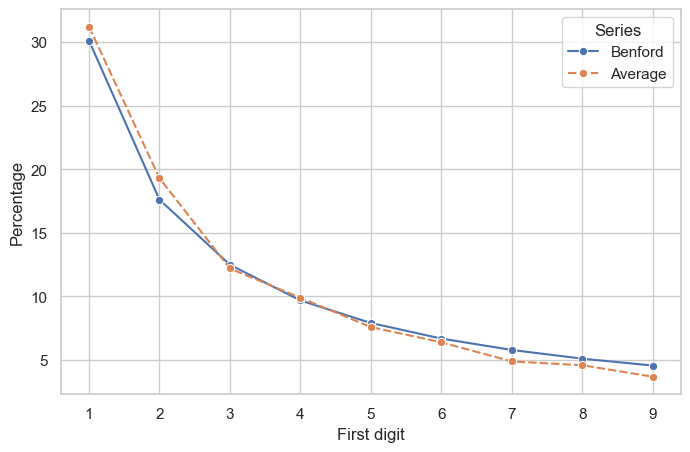

In [13]:
if 'probabilities' not in globals():
    digits = np.arange(1, 10)
    probabilities = np.log10((digits + 1) / digits)
else:
    digits = np.arange(1, 10)
benford = 100 * probabilities
average = np.array([31.2, 19.3, 12.2, 9.9, 7.6, 6.4, 4.9, 4.6, 3.7])
df = pd.DataFrame({
    'Digit': np.concatenate([digits, digits]),
    'Percentage': np.concatenate([benford, average]),
    'Series': ['Benford'] * 9 + ['Average'] * 9,
})
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df, x='Digit', y='Percentage', hue='Series', style='Series', marker='o', ax=ax)
ax.set_xlabel('First digit')
ax.set_ylabel('Percentage')
plt.show()


## Inventory data


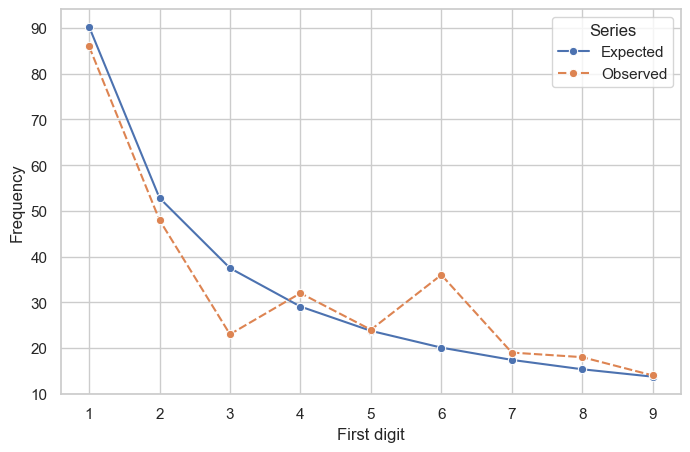

In [14]:
if 'probabilities' not in globals():
    digits = np.arange(1, 10)
    probabilities = np.log10((digits + 1) / digits)
else:
    digits = np.arange(1, 10)
inv_expected = 300 * probabilities
inv_observed = np.array([86, 48, 23, 32, 24, 36, 19, 18, 14])
df_inv = pd.DataFrame({
    'Digit': np.concatenate([digits, digits]),
    'Frequency': np.concatenate([inv_expected, inv_observed]),
    'Series': ['Expected'] * 9 + ['Observed'] * 9,
})
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_inv, x='Digit', y='Frequency', hue='Series', style='Series', marker='o', ax=ax)
ax.set_xlabel('First digit')
ax.set_ylabel('Frequency')
plt.show()


Calculation of the test statistic


In [15]:
# Expected
np.round(inv_expected, 2)


array([90.31, 52.83, 37.48, 29.07, 23.75, 20.08, 17.4 , 15.35, 13.73])

In [16]:
# Obs - Exp squared
np.round((inv_observed - inv_expected)**2, 2)


array([1.8570e+01, 2.3300e+01, 2.0972e+02, 8.5700e+00, 6.0000e-02,
       2.5332e+02, 2.5700e+00, 7.0500e+00, 7.0000e-02])

In [17]:
# Obs - Exp squared divided by expected
np.round(((inv_observed - inv_expected)**2 / inv_expected), 2)
sum(np.round(((inv_observed - inv_expected)**2 / inv_expected), 2))


np.float64(19.77)

Critical region


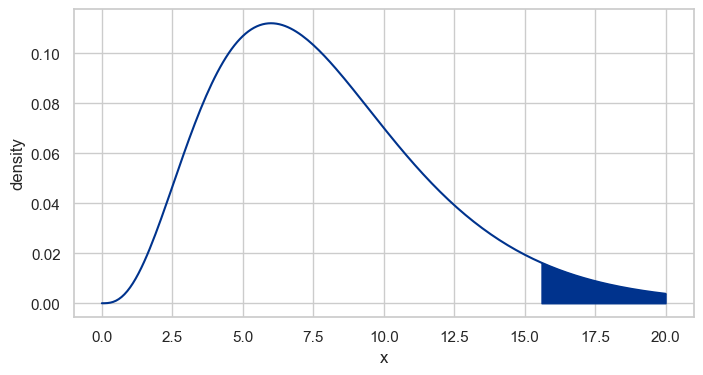

In [18]:
df = 8
x = np.arange(0, 20.1, 0.1)
tail_start = 15.51
y = chi2.pdf(x, df=df)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color='#00338D')
mask = x >= tail_start
ax.fill_between(x[mask], y[mask], color='#00338D', alpha=1.0)
ax.set_xlabel('x')
ax.set_ylabel('density')
plt.show()


Using the built-in test


In [19]:
(lambda _obs, _p: chisquare(f_obs=_obs, f_exp=_obs.sum() * (_p / _p.sum())))(np.asarray(inv_observed, dtype=float), np.asarray(probabilities, dtype=float))


Power_divergenceResult(statistic=np.float64(19.764146088879812), pvalue=np.float64(0.01126616123069587))

## Discrete Uniform Distribution


Text(0.5, 1.0, 'First')

Text(0.5, 0, 'Digit')

Text(0, 0.5, 'Probability')

Text(0.5, 1.0, 'Second')

Text(0.5, 0, 'Digit')

Text(0, 0.5, 'Probability')

Text(0.5, 1.0, 'Third')

Text(0.5, 0, 'Digit')

Text(0, 0.5, 'Probability')

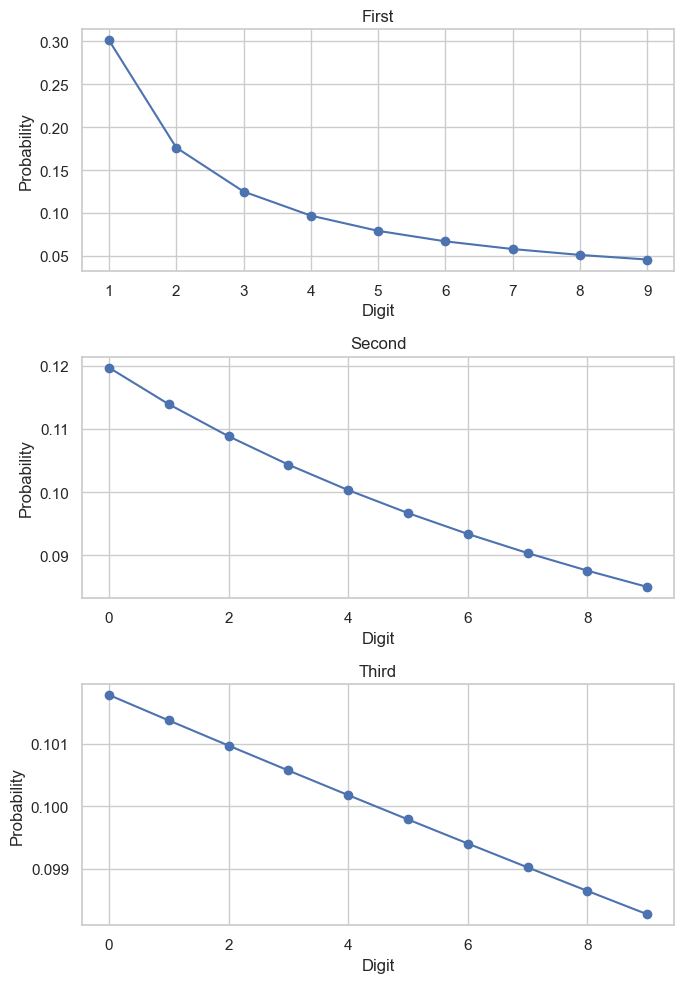

In [20]:
from IPython.display import display
first_digit = pd.DataFrame({
    'digit': np.arange(1, 10),
    'probability': np.log10(1 + 1 / np.arange(1, 10)),
    'position': 'First',
})
second_digit = pd.DataFrame({
    'digit': np.arange(0, 10),
    'probability': [sum(np.log10(1 + 1 / (10 * np.arange(1, 10) + d))) for d in range(10)],
    'position': 'Second',
})
third_digit = pd.DataFrame({
    'digit': np.arange(0, 10),
    'probability': [sum(np.log10(1 + 1 / (10 * np.arange(10, 100) + d))) for d in range(10)],
    'position': 'Third',
})
benford_data = pd.concat([first_digit, second_digit, third_digit], ignore_index=True)
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=False)
for idx, position in enumerate(['First', 'Second', 'Third']):
    subset = benford_data[benford_data['position'] == position]
    display(axes[idx].plot(subset['digit'], subset['probability'], marker='o'))
    display(axes[idx].set_title(position))
    display(axes[idx].set_xlabel('Digit'))
    display(axes[idx].set_ylabel('Probability'))
plt.tight_layout()
plt.show()


In [21]:
if 'ussteamco_mod_3_residuals' in globals():
    nres = np.asarray(ussteamco_mod_3_residuals) / np.std(ussteamco_mod_3_residuals)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for ax, bins in zip(axes.flatten(), [6, 7, 8, 9]):
        sns.histplot(nres, bins=bins, stat='density', color='#00338D', edgecolor='black', ax=ax)
        x = np.linspace(np.min(nres), np.max(nres), 200)
        ax.plot(x, norm.pdf(x, np.mean(nres), np.std(nres)), color='red')
        ax.set_title(f'Histogram with {bins} bins')
        ax.set_xlabel('Standardized Residuals')
        ax.set_ylabel('Density')
    plt.tight_layout()
    plt.show()
else:
    print('Skipped residual histogram example: source R object ussteamco.mod.3 is not available in Python track.')


Skipped residual histogram example: source R object ussteamco.mod.3 is not available in Python track.
